In [ ]:
"""
fitters_test.ipynb

Tests the fitter object, meant to 
fit all models to a given session.

Author: Stellina X. Ao
Created: 2026-03-05
Last Modified: 2026-03-05
Python Version: 3.11.14
"""

from sg.fitter import LVMFamily
from sg import utils
from squiggs.neuron_viewer import NeuronViewer
from squiggs.renderers import FitRenderer
from sg.eval_models import plot_summary

import scienceplots  # noqa: F401
import shutup
import matplotlib.pyplot as plt
import pickle
import numpy as np

%load_ext autoreload
%autoreload 2

# pretty plots
plt.style.use(["nature"])
plt.rcParams["figure.dpi"] = 200
%matplotlib widget
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

# seed and suppress warnings :-)
# fitlvm_utils.seed()
shutup.please()

In [35]:
"""
TODO:

"""

'\nTODO:\n\n'

## Fit one session with 4 additive latents

In [4]:
trial_data_all = np.load(
    "../vars/trial_data_all_MM012_MM013_all5.npz", allow_pickle=True
)["arr_0"]
session_data_all = np.load(
    "../vars/session_data_all_MM012_MM013_all5.npz", allow_pickle=True
)["arr_0"]
unit_spike_times_all = np.load(
    "../vars/unit_spike_times_all_MM012_MM013_all5.npz", allow_pickle=True
)["arr_0"]
regions_all = np.load("../vars/regions_all_MM012_MM013_all5.npz", allow_pickle=True)[
    "arr_0"
]

subj_idx = 0
sess_idx = 5

unit_spike_times = unit_spike_times_all[subj_idx][sess_idx]
trial_data = trial_data_all[subj_idx][sess_idx]
session_data = session_data_all[subj_idx][sess_idx]
regions = regions_all[subj_idx][sess_idx]
trial_data["block_side"] = np.where(trial_data["block_side"] == "left", 1, -1)

In [26]:
family = LVMFamily(
    trial_data=trial_data,
    spike_times=unit_spike_times,
    session_data=session_data,
    regions=regions,
    n_latents_mult=4,
    n_latents_addt=4,
    sanity_check=2,
)
# family.get_data()
family.fit_all()

multiplying poor dms by 2sin+0.5cos+2.5


In [34]:
family.eval()
family.res_gain["r2test"].mean()

tensor(0.3689)

In [32]:
potato = (
    2 * np.sin(np.arange(family.psths["DMS"].shape[1]))
    + 0.5 * np.cos(np.arange(family.psths["DMS"].shape[1]))
    + 2.5
)

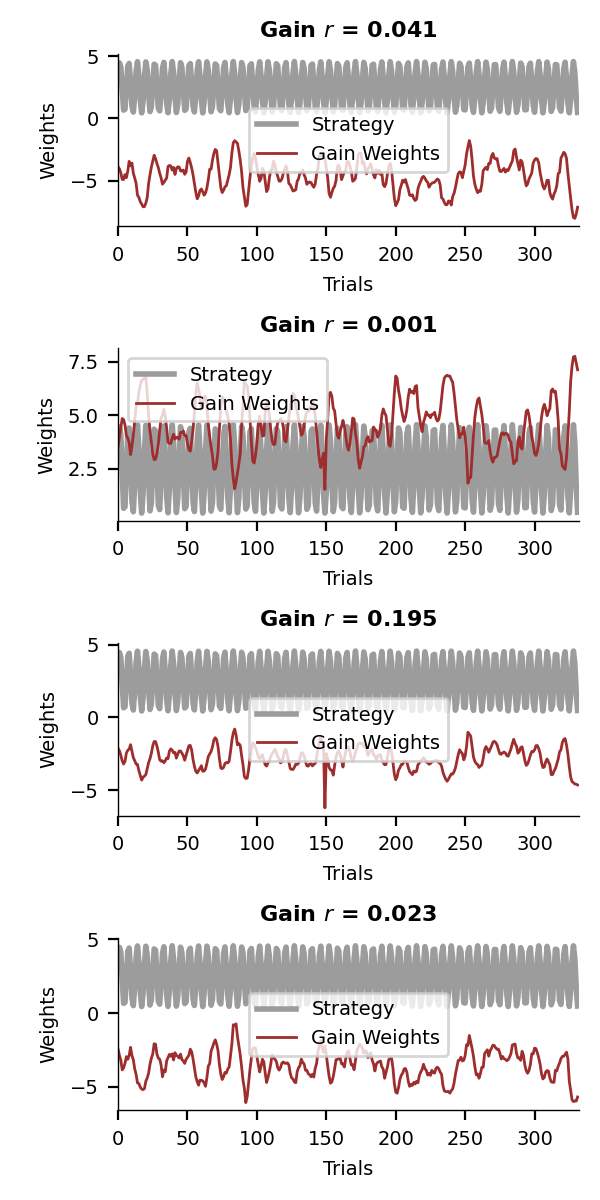

In [ ]:
plot_summary(family, model=family.mod_gain, potato=potato, mode="gain")

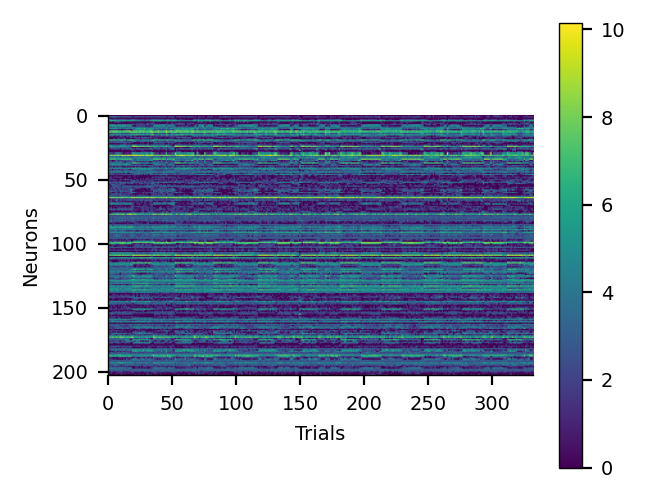

In [14]:
plt.figure()
plt.imshow(family.robs.T)
plt.xlabel("Trials")
plt.ylabel("Neurons")
plt.colorbar()
plt.tight_layout()
plt.show()

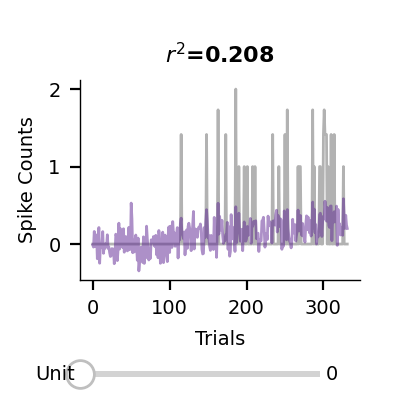

In [ ]:
render_baseline = FitRenderer(
    family.mod_ae_gain,
    x=family.test_dl.dataset[:],
    y=family.test_dl.dataset[:]["robs"].detach().cpu(),
)

nv = NeuronViewer(num_units=render_baseline.y.shape[1], render_func=render_baseline)

In [4]:
with open("../vars/family.pkl", "wb") as f:
    pickle.dump(family, f)

In [5]:
with open("../vars/family.pkl", "rb") as f:
    family = pickle.load(f)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


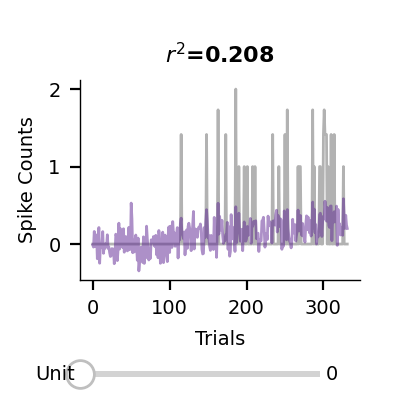

In [ ]:
render_baseline = FitRenderer(
    family.mod_ae_gain,
    x=family.test_dl.dataset[:],
    y=family.test_dl.dataset[:]["robs"].detach().cpu(),
)
nv = NeuronViewer(num_units=render_baseline.y.shape[1], render_func=render_baseline)

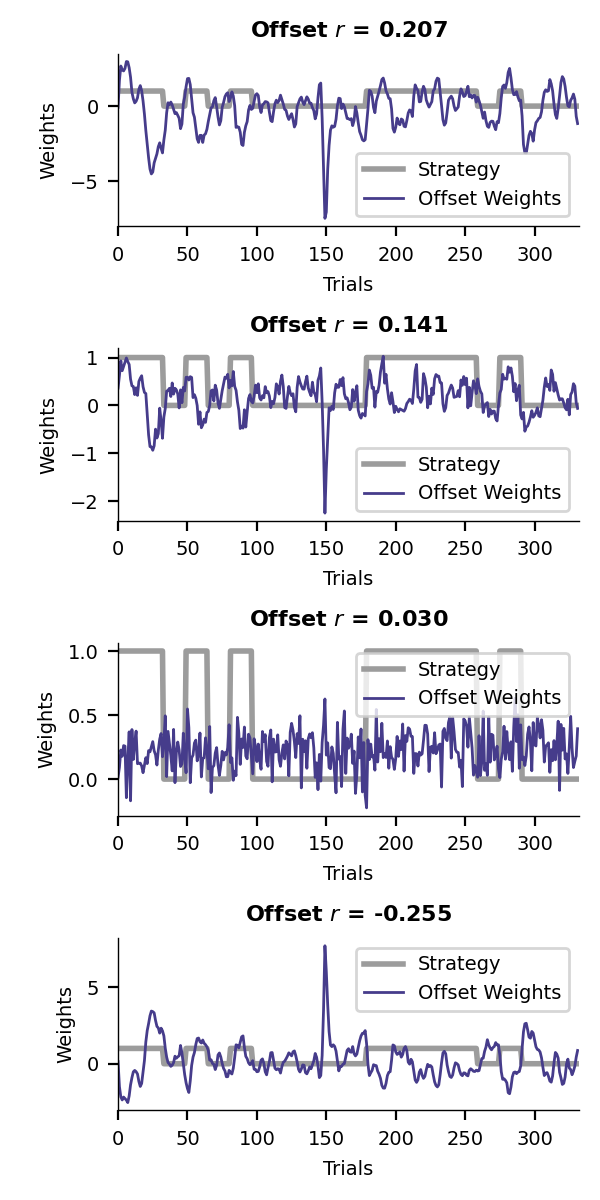

In [ ]:
plot_summary(family, family.mod_offset, potato=family.strategy, mode="")

In [ ]:
robs = family.val_dl.dataset[:]["robs"]
rhat = family.res_taskvar["rhat"]
res = robs - rhat

block_side = family.block_side
choice = family.response
reward = family.rewarded

rob_block_corr = utils.spearmanr_vec(block_side, robs)
rob_choice_corr = utils.spearmanr_vec(choice, robs)
rob_reward_corr = utils.spearmanr_vec(reward, robs)
res_block_corr = utils.spearmanr_vec(block_side, res)
res_choice_corr = utils.spearmanr_vec(choice, res)
res_reward_corr = utils.spearmanr_vec(reward, res)

C:\Users\danci\AppData\Local\Temp\ipykernel_8276\40825719.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  res = robs - rhat


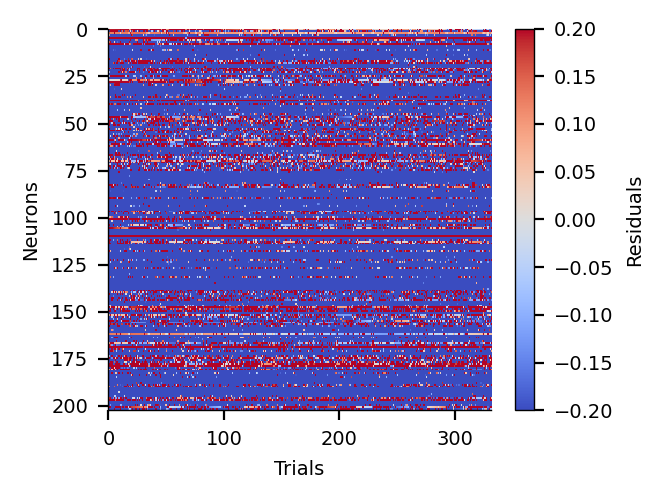

In [24]:
plt.figure()
plt.imshow(
    res.T, aspect="auto", interpolation="none", cmap="coolwarm", vmin=-0.2, vmax=0.2
)
plt.colorbar(label="Residuals")
plt.xlabel("Trials")
plt.ylabel("Neurons")
plt.tight_layout()
plt.show()

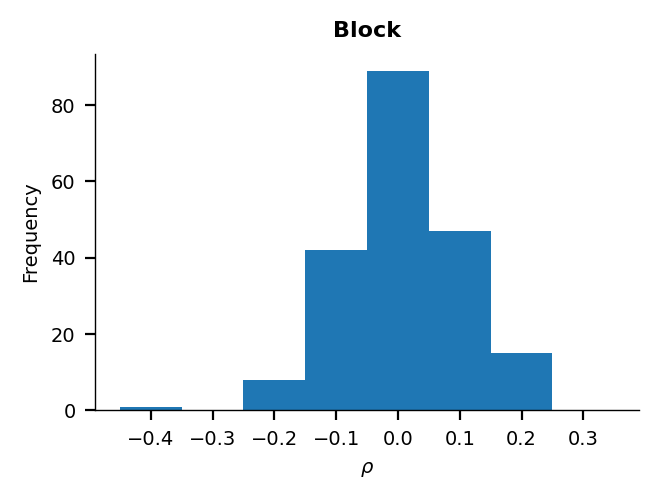

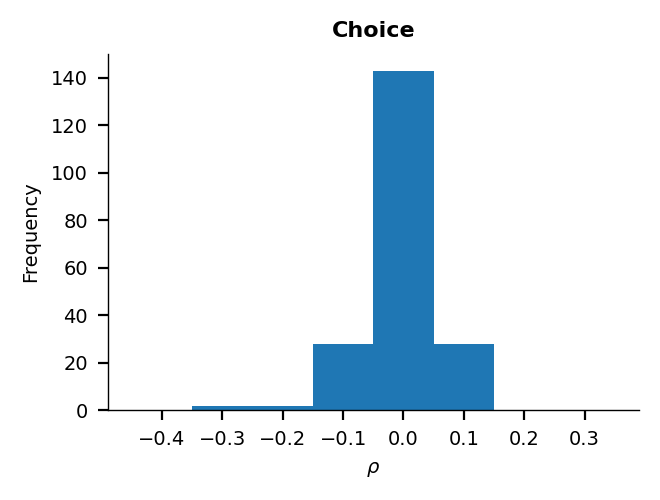

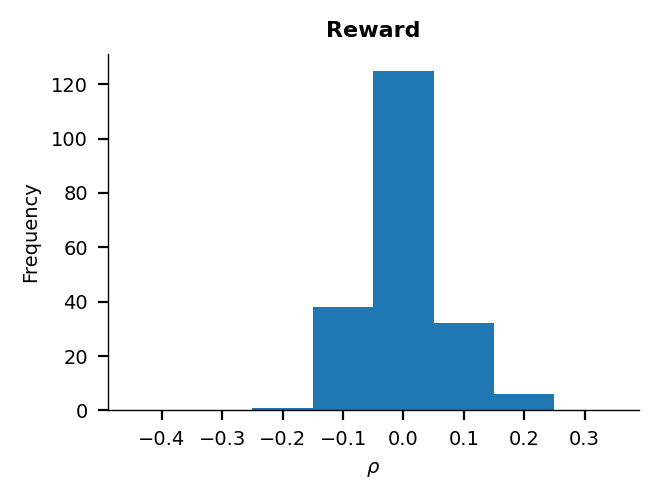

In [21]:
plt.figure()
plt.hist(res_block_corr, bins=np.arange(-0.45, 0.45, 0.1))
plt.xlabel(r"$\rho$")
plt.ylabel("Frequency")
plt.title("Block")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(res_choice_corr, bins=np.arange(-0.45, 0.45, 0.1))
plt.xlabel(r"$\rho$")
plt.ylabel("Frequency")
plt.title("Choice")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(res_reward_corr, bins=np.arange(-0.45, 0.45, 0.1))
plt.xlabel(r"$\rho$")
plt.ylabel("Frequency")
plt.title("Reward")
plt.tight_layout()
plt.show()

## Plot r2 matrix

In [1]:
import pickle
import numpy as np

m_latents = np.arange(1, 10 + 1)  # 10, 10)
a_latents = np.arange(1, 10 + 1)  # 10, 10)

r2s = np.zeros((len(m_latents), len(a_latents)))
for i, m in enumerate(m_latents):
    for j, a in enumerate(a_latents):
        with open(f"../vars/families/family-m{int(m)}a{int(a)}.pkl", "rb") as f:
            family_ = pickle.load(f)
            family_.eval()
            r2s[i, j] = family_.res_affine["r2test"].mean()

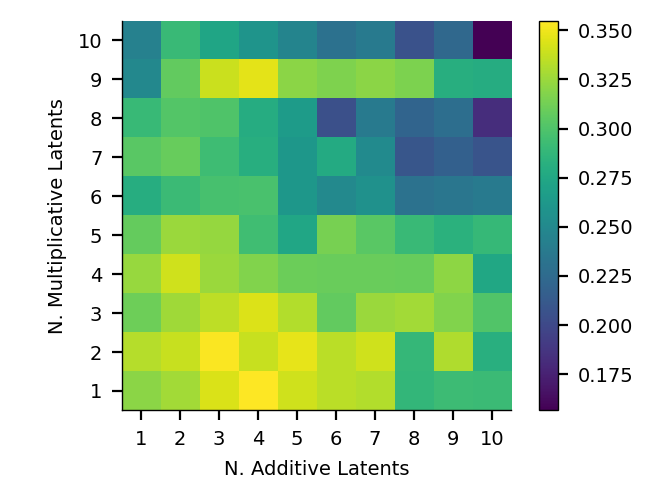

In [2]:
import matplotlib.pyplot as plt

plt.style.use(["nature"])
plt.rcParams["figure.dpi"] = 200
%matplotlib widget

plt.figure()
plt.imshow(r2s, origin="lower", interpolation=None)
plt.xlabel("N. Additive Latents")
plt.ylabel("N. Multiplicative Latents")
plt.xticks(np.arange(len(a_latents)), np.arange(1, len(a_latents) + 1))
plt.yticks(np.arange(len(a_latents)), np.arange(1, len(a_latents) + 1))
plt.colorbar()
plt.tight_layout()
plt.show()

## Check latents

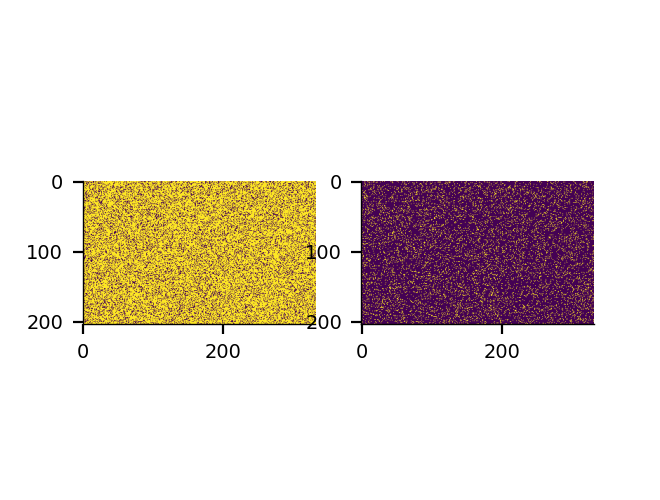

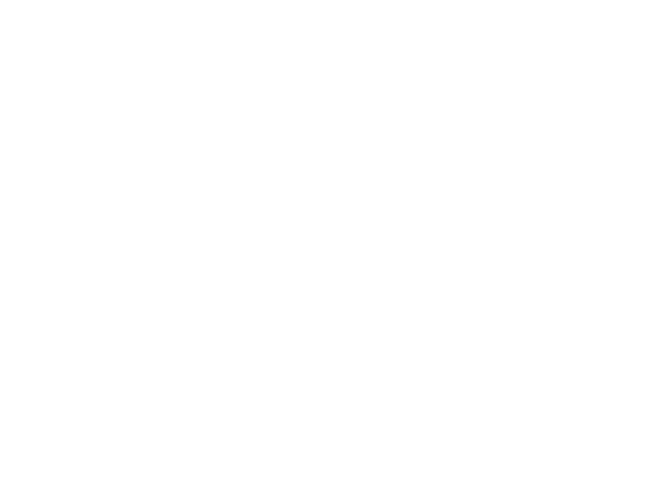

In [24]:
plt.figure()
fig, axes = plt.subplots(ncols=2)
axes[0].imshow(family.train_dl.dataset[:]["dfs"].T)
axes[1].imshow(family.test_dl.dataset[:]["dfs"].T)
plt.show()

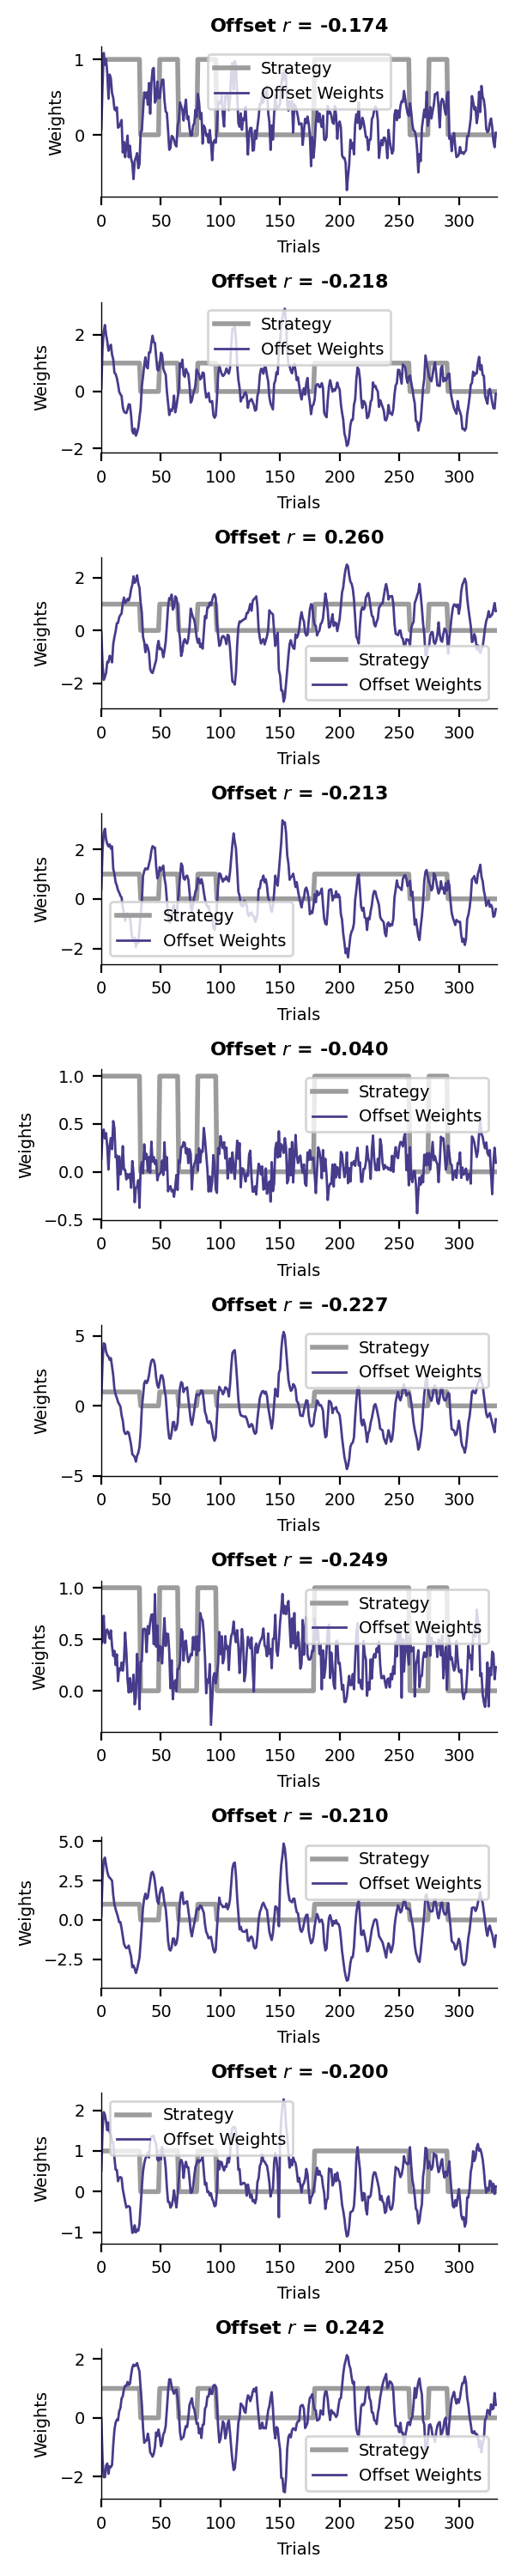

In [ ]:
m = 4
a = 10

with open(f"../vars/families/midnight-run/family-m{m}a{a}.pkl", "rb") as f:
    family = pickle.load(f)
family.eval()

plot_summary(family, family.mod_offset, potato=family.strategy, mode="offset")

## Correlate latents

In [ ]:
# m=4
# a=10
# with open(f"../vars/families/midnight-run/family-m{m}a{a}.pkl", "rb") as f:
#     family = pickle.load(f)

# # only focus on offset for now
# model =